#📊 PROYECTO: SCRAPPING PARA CAMPAÑA DE MARKETING GASTRONÓMICO EN MENDOZA

---


***🎯 OBJETIVO ESTRATÉGICO***

**Extraer datos para una campaña de marketing gastronómico en Mendoza, analizando el sector y proyectando al 2026.**


#ARQUITECTURA  - 4 CAPAS:

1. CAPA DE EXTRACCIÓN (Crawling/Scrapping)
   └── Fuentes reales de Mendoza + APIs oficiales

2. CAPA DE PERSISTENCIA (Base de Datos)
   └── PostgreSQL/SQLite + Modelos de datos

3. CAPA DE VISUALIZACIÓN (Dashboard Web)
   └── Streamlit/Plotly + Visualizaciones interactivas

4. CAPA DE AUTOMATIZACIÓN (Orquestación)
   └── Cron/Airflow + Monitoreo + Alertas
"""

#Librerías

**FLUJO DE TRABAJO:**
---

1. REQUESTS → Descarga página web
   ↓
2. BEAUTIFULSOUP + RE → Extrae datos específicos
   ↓
3. PANDAS → Organiza datos en tablas
   ↓
4. SQLALCHEMY → Guarda en base de datos
   ↓
5. PLOTLY → Crea visualizaciones
   ↓
6. SCHEDULE → Programa extracciones automáticas

# SECCIÓN 2: EXTRACCIÓN DE DATOS REALES


---
**Datos gubernamentales:**

https://investinmendoza.com/

https://datos.gob.ar/

https://www.indec.gob.ar/

https://www.mendoza.gob.ar/

https://informacionoficial.mendoza.gob.ar/


**Datos cámaras empresariales:**

https://aehga.com/

https://uthgra.org.ar/

https://fehgra.org.ar/



In [ ]:
# ============================================================================
# 🎯 SECCIÓN 2: EXTRACCIÓN DE DATOS DE GASTRONOMÍA - Invest in Mendoza
# ============================================================================

# 📦 1. IMPORTACIONES NECESARIAS
import requests
from bs4 import BeautifulSoup
import pandas as pd
from datetime import datetime
import re
import urllib.parse

print("✅ Librerías importadas correctamente")
print("=" * 60)

# 🔧 2. FUNCIÓN PRINCIPAL DE EXTRACCIÓN
def extraer_noticias_gastronomia(url):
    """Extrae noticias de gastronomía de Invest in Mendoza usando los selectores CORRECTOS"""

    print(f"🔍 Conectando a: {url}")
    print(f"   Búsqueda: 'Gastronomía'")

    # A) DESCARGAR LA PÁGINA
    try:
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
            'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
            'Accept-Language': 'es-ES,es;q=0.9',
            'Accept-Encoding': 'gzip, deflate',
            'Connection': 'keep-alive',
        }

        response = requests.get(url, headers=headers, timeout=15)
        response.raise_for_status()  # Verifica errores HTTP
        soup = BeautifulSoup(response.text, 'html.parser')
        print("   ✅ Página descargada correctamente")

    except requests.exceptions.Timeout:
        print("   ⏱️  Timeout: El servidor tardó demasiado en responder")
        return []
    except requests.exceptions.HTTPError as e:
        print(f"   ❌ Error HTTP {e.response.status_code}")
        return []
    except Exception as e:
        print(f"   ❌ Error al descargar: {e}")
        return []

    # B) BUSCAR CONTENEDOR DE NOTICIAS
    # Selector exacto basado en tu análisis HTML: <ul class="... wp-block-post-template ...">
    lista_noticias = soup.find('ul', class_='wp-block-post-template')

    if not lista_noticias:
        print("   ⚠️ No se encontró el contenedor principal de noticias")
        # Intentar otro selector alternativo
        lista_noticias = soup.find('ul', class_=lambda x: x and 'post-template' in str(x))
        if not lista_noticias:
            print("   ❌ No se encontraron noticias con los selectores actuales")
            return []

    # C) ENCONTRAR CADA NOTICIA INDIVIDUAL
    # Selector: <li class="wp-block-post"> dentro del <ul>
    articulos = lista_noticias.find_all('li', class_='wp-block-post')

    print(f"   📊 Encontradas {len(articulos)} noticias de gastronomía para procesar")

    if len(articulos) == 0:
        print("   ℹ️  La búsqueda no devolvió resultados")
        return []

    datos_extraidos = []
    noticias_procesadas = 0

    # D) PROCESAR CADA NOTICIA
    for i, art in enumerate(articulos, 1):
        try:
            # Extraer TÍTULO y ENLACE
            titulo_elem = art.find('h2', class_='wp-block-post-title')
            if titulo_elem:
                enlace_elem = titulo_elem.find('a')
                titulo = enlace_elem.text.strip() if enlace_elem else "Sin título"
                enlace = enlace_elem.get('href', '#') if enlace_elem else '#'

                # Asegurar que el enlace sea completo
                if enlace and enlace.startswith('/'):
                    enlace = 'https://investinmendoza.com' + enlace
            else:
                titulo = "Sin título"
                enlace = "#"

            # Extraer FECHA
            fecha_elem = art.find('time')
            fecha_texto = fecha_elem.text.strip() if fecha_elem else "Sin fecha"
            fecha_datetime = fecha_elem.get('datetime') if fecha_elem and fecha_elem.get('datetime') else fecha_texto

            # Extraer AUTOR
            autor_elem = art.find('div', class_='wp-block-post-author-name')
            autor = autor_elem.text.strip() if autor_elem else "Sin autor"

            # Extraer RESUMEN
            resumen_elem = art.find('p', class_='wp-block-post-excerpt__excerpt')
            resumen = resumen_elem.text.strip() if resumen_elem else "Sin resumen"

            # Extraer CATEGORÍAS (de las clases del <li>)
            clases = art.get('class', [])
            categorias = []
            for clase in clases:
                if 'category-' in clase:
                    # Limpiar el nombre de la categoría
                    categoria_limpia = clase.replace('category-', '').replace('-', ' ').title()
                    categorias.append(categoria_limpia)

            # Extraer ETIQUETAS (tags) - si están disponibles en el HTML
            tags = []
            # Buscar elementos de tag en el artículo
            tag_elements = art.find_all(['a', 'span'], class_=lambda x: x and 'tag' in str(x).lower())
            for tag_elem in tag_elements:
                tag_text = tag_elem.text.strip()
                if tag_text and tag_text not in tags:
                    tags.append(tag_text)

            # Verificar IMAGEN
            tiene_imagen = bool(art.find('img'))

            # Extraer AÑO de la fecha para filtrado
            año_publicacion = None
            if fecha_datetime and len(fecha_datetime) >= 4:
                # Intentar extraer el año del datetime attribute
                año_match = re.search(r'(\d{4})', fecha_datetime)
                if año_match:
                    año_publicacion = año_match.group(1)

            # Evaluar RELEVANCIA para campaña 2026
            relevancia = "Media"
            texto_completo = f"{titulo} {resumen}".lower()

            palabras_clave_alta = ['michelin', 'estrella', 'gala', 'itb', 'berlín', 'europeo', 'internacional', 'lujo', 'luxury', 'premium']
            palabras_clave_media = ['gastronomía', 'enoturismo', 'turismo', 'vino', 'bodega', 'restaurante', 'chef']

            if any(palabra in texto_completo for palabra in palabras_clave_alta):
                relevancia = "Alta"
            elif any(palabra in texto_completo for palabra in palabras_clave_media):
                relevancia = "Media"
            else:
                relevancia = "Baja"

            # Verificar si es proyección futura (2025-2026)
            es_proyeccion_futura = any(str(year) in texto_completo for year in ['2025', '2026', '2027'])

            # Guardar en lista
            datos_extraidos.append({
                'ID': f"GASTRO-{i:03d}",
                'Titulo': titulo,
                'Enlace': enlace,
                'Fecha_Texto': fecha_texto,
                'Fecha_Datetime': fecha_datetime,
                'Año_Publicacion': año_publicacion,
                'Autor': autor,
                'Resumen': resumen[:200] + "..." if len(resumen) > 200 else resumen,
                'Categorias': ', '.join(categorias[:5]),  # Máximo 5 categorías
                'Tags': ', '.join(tags[:10]),  # Máximo 10 tags
                'Tiene_Imagen': 'Sí' if tiene_imagen else 'No',
                'Relevancia_Campana': relevancia,
                'Es_Proyeccion_Futura': 'Sí' if es_proyeccion_futura else 'No',
                'Fuente': 'Invest in Mendoza',
                'Tipo_Contenido': 'Noticia Gastronomía',
                'Fecha_Extraccion': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                'URL_Busqueda': url
            })

            noticias_procesadas += 1
            print(f"   ✅ [{i}/{len(articulos)}] {titulo[:50]}...")

        except Exception as e:
            print(f"   ⚠️ Error en noticia {i}: {str(e)[:50]}")
            continue

    # E) VERIFICAR PAGINACIÓN (para extraer más páginas si existen)
    pagination = soup.find('nav', class_='wp-block-query-pagination')
    paginas_totales = 1

    if pagination:
        page_numbers = pagination.find_all('a', class_='page-numbers')
        if page_numbers:
            # Encontrar el número de página más alto
            numeros = []
            for page in page_numbers:
                if page.text.isdigit():
                    numeros.append(int(page.text))

            if numeros:
                paginas_totales = max(numeros)
                print(f"   📄 Se detectaron {paginas_totales} páginas de resultados")

    return {
        'noticias': datos_extraidos,
        'estadisticas': {
            'total_encontradas': len(articulos),
            'total_procesadas': noticias_procesadas,
            'paginas_totales': paginas_totales,
            'url_busqueda': url,
            'termino_busqueda': 'Gastronomía'
        }
    }

# 🔄 3. FUNCIÓN PARA EXTRAER MÚLTIPLES PÁGINAS
def extraer_todas_paginas_gastronomia(termino_busqueda="Gastronomía", max_paginas=3):
    """Extrae noticias de todas las páginas de resultados"""

    print(f"\n🔍 INICIANDO EXTRACCIÓN COMPLETA PARA: '{termino_busqueda}'")
    print("-" * 60)

    todas_noticias = []
    estadisticas_totales = {
        'noticias_totales': 0,
        'paginas_procesadas': 0,
        'termino_busqueda': termino_busqueda
    }

    for pagina in range(1, max_paginas + 1):
        # Construir URL para cada página
        if pagina == 1:
            url = f"https://investinmendoza.com/?s={urllib.parse.quote(termino_busqueda)}"
        else:
            url = f"https://investinmendoza.com/page/{pagina}/?s={urllib.parse.quote(termino_busqueda)}"

        print(f"\n📄 Procesando página {pagina}...")
        print(f"   URL: {url}")

        resultado = extraer_noticias_gastronomia(url)

        if resultado['noticias']:
            todas_noticias.extend(resultado['noticias'])
            estadisticas_totales['noticias_totales'] += resultado['estadisticas']['total_procesadas']
            estadisticas_totales['paginas_procesadas'] += 1

            # Si no hay más páginas, salir del bucle
            if pagina >= resultado['estadisticas']['paginas_totales']:
                print(f"   ℹ️  Última página alcanzada (total: {resultado['estadisticas']['paginas_totales']})")
                break

        # Pausa para ser amable con el servidor
        import time
        if pagina < max_paginas:
            time.sleep(2)  # 2 segundos entre peticiones

    return {
        'todas_noticias': todas_noticias,
        'estadisticas_totales': estadisticas_totales
    }

# 🚀 4. EJECUCIÓN PRINCIPAL
if __name__ == "__main__":
    print("\n" + "="*70)
    print("🚀 SISTEMA DE EXTRACCIÓN: GASTRONOMÍA MENDOZA 2024-2026")
    print("="*70)

    # OPCIÓN A: Extraer solo la primera página
    # url_objetivo = "https://investinmendoza.com/?s=Gastronom%C3%ADa"
    # resultado = extraer_noticias_gastronomia(url_objetivo)
    # noticias_extraidas = resultado['noticias']

    # OPCIÓN B: Extraer múltiples páginas (RECOMENDADO)
    resultado_completo = extraer_todas_paginas_gastronomia(
        termino_busqueda="Gastronomía",
        max_paginas=6
    )

    noticias_extraidas = resultado_completo['todas_noticias']
    estadisticas = resultado_completo['estadisticas_totales']

    # Mostrar resultados
    if noticias_extraidas:
        # Convertir a DataFrame de pandas
        df_noticias = pd.DataFrame(noticias_extraidas)

        print(f"\n{'='*70}")
        print("✅ ¡EXTRACCIÓN COMPLETADA CON ÉXITO!")
        print(f"{'='*70}")

        # Estadísticas generales
        print(f"\n📊 ESTADÍSTICAS DE EXTRACCIÓN:")
        print(f"   • Páginas procesadas: {estadisticas['paginas_procesadas']}")
        print(f"   • Noticias totales extraídas: {len(df_noticias)}")
        print(f"   • Término de búsqueda: '{estadisticas['termino_busqueda']}'")

        # Análisis de relevancia
        if 'Relevancia_Campana' in df_noticias.columns:
            relevancia_counts = df_noticias['Relevancia_Campana'].value_counts()
            print(f"\n🎯 RELEVANCIA PARA CAMPAÑA 2026:")
            for nivel, count in relevancia_counts.items():
                print(f"   • {nivel}: {count} noticias")

        # Análisis temporal
        if 'Año_Publicacion' in df_noticias.columns:
            año_counts = df_noticias['Año_Publicacion'].value_counts()
            print(f"\n📅 DISTRIBUCIÓN POR AÑO:")
            for año, count in año_counts.head(5).items():
                if año:
                    print(f"   • {año}: {count} noticias")

        # Noticias de proyección futura
        if 'Es_Proyeccion_Futura' in df_noticias.columns:
            futuras = df_noticias[df_noticias['Es_Proyeccion_Futura'] == 'Sí']
            print(f"\n🚀 NOTICIAS CON PROYECCIÓN FUTURA (2025-2026): {len(futuras)}")
            if len(futuras) > 0:
                for idx, fila in futuras.head(3).iterrows():
                    print(f"   • {fila['Titulo'][:60]}...")

        # Mostrar vista previa detallada
        print(f"\n{'='*70}")
        print("📋 VISTA PREVIA DETALLADA (primeras 5 noticias):")
        print(f"{'='*70}")

        for idx, fila in df_noticias.head(5).iterrows():
            print(f"\n{fila['ID']}. {fila['Titulo'][:70]}...")
            print(f"   📅 {fila['Fecha_Texto']} | 👤 {fila['Autor']}")
            print(f"   📝 {fila['Resumen'][:100]}...")
            print(f"   🏷️ Categorías: {fila['Categorias']}")
            print(f"   ⭐ Relevancia: {fila['Relevancia_Campana']}")
            print(f"   🖼️ Imagen: {fila['Tiene_Imagen']}")
            if fila['Es_Proyeccion_Futura'] == 'Sí':
                print(f"   🚀 PROYECCIÓN FUTURA: Sí")

        # Guardar en CSV
        nombre_archivo = 'gastronomia_invest_mendoza.csv'
        df_noticias.to_csv(nombre_archivo, index=False, encoding='utf-8')
        print(f"\n💾 Datos guardados en: '{nombre_archivo}'")

        # Guardar también en Excel para mejor visualización
       # Guardar también en Excel para mejor visualización
try:
    excel_nombre = 'gastronomia_invest_mendoza.xlsx'
    df_noticias.to_excel(excel_nombre, index=False)
    print(f"💾 Datos también guardados en: '{excel_nombre}'")

    # Mostrar información del archivo generado
    import os
    if os.path.exists(excel_nombre):
        file_size = os.path.getsize(excel_nombre) / 1024  # Tamaño en KB
        print(f"   📏 Tamaño del archivo: {file_size:.2f} KB")
        print(f"   📍 Ruta completa: {os.path.abspath(excel_nombre)}")

except Exception as e:
    print(f"   ❌ Error al guardar en Excel: {e}")
    print(f"   🛠️  Instalando dependencia necesaria...")
    !pip install openpyxl
    # Intentar de nuevo
    try:
        df_noticias.to_excel(excel_nombre, index=False, engine='openpyxl')
        print(f"   ✅ Archivo Excel generado después de instalar openpyxl")
    except Exception as e2:
        print(f"   ❌ Error persistente: {e2}")

        # Generar reporte de análisis
        print(f"\n{'='*70}")
        print("🎯 ANÁLISIS PARA CAMPAÑA DE MARKETING 2026:")
        print(f"{'='*70}")

        # Puntos clave encontrados
        puntos_clave = []

        # 1. Eventos internacionales
        eventos_int = df_noticias[df_noticias['Titulo'].str.contains('ITB|Berlín|Michelin|Gala|Internacional', case=False, na=False)]
        if len(eventos_int) > 0:
            puntos_clave.append(f"• {len(eventos_int)} eventos/reconocimientos internacionales (ITB Berlín, Michelin)")

        # 2. Reconocimientos
        reconocimientos = df_noticias[df_noticias['Titulo'].str.contains('Michelin|Estrella|Llave|Reconocimiento|Premio', case=False, na=False)]
        if len(reconocimientos) > 0:
            puntos_clave.append(f"• {len(reconocimientos)} noticias sobre reconocimientos gastronómicos")

        # 3. Turismo y enoturismo
        turismo = df_noticias[df_noticias['Titulo'].str.contains('Turismo|Enoturismo|Destino|Lujo', case=False, na=False)]
        if len(turismo) > 0:
            puntos_clave.append(f"• {len(turismo)} noticias sobre turismo y enoturismo")

        # Mostrar puntos clave
        if puntos_clave:
            print("\n🔑 PUNTOS CLAVE IDENTIFICADOS:")
            for punto in puntos_clave:
                print(f"   {punto}")

        # Recomendaciones para la campaña
        print(f"\n💡 RECOMENDACIONES PARA LA CAMPAÑA 2026:")
        print(f"   1. Capitalizar reconocimientos Michelin como sello de calidad")
        print(f"   2. Posicionar Mendoza como destino de turismo gastronómico de lujo")
        print(f"   3. Destacar participación en ferias internacionales (ITB Berlín)")
        print(f"   4. Crear contenido sobre bodegas y experiencias enoturísticas")
        print(f"   5. Desarrollar alianzas con restaurantes con estrellas Michelin")



    else:
        print("\n❌ No se pudieron extraer noticias.")
        print("   Posibles causas:")
        print("   1. La estructura de la página cambió")
        print("   2. No hay resultados para la búsqueda")
        print("   3. El sitio bloquea solicitudes automatizadas")
        print("\n   💡 Solución: Verifica manualmente la página en tu navegador")

print(f"\n{'='*70}")
print("🏁 FIN DE LA EXTRACCIÓN: DATOS DE GASTRONOMÍA MENDOZA")
print(f"{'='*70}")

✅ Librerías importadas correctamente

🚀 SISTEMA DE EXTRACCIÓN: GASTRONOMÍA MENDOZA 2024-2026

🔍 INICIANDO EXTRACCIÓN COMPLETA PARA: 'Gastronomía'
------------------------------------------------------------

📄 Procesando página 1...
   URL: https://investinmendoza.com/?s=Gastronom%C3%ADa
🔍 Conectando a: https://investinmendoza.com/?s=Gastronom%C3%ADa
   Búsqueda: 'Gastronomía'
   ✅ Página descargada correctamente
   📊 Encontradas 10 noticias de gastronomía para procesar
   ✅ [1/10] Mendoza brilla en ITB Berlín 2025: enoturismo, gas...
   ✅ [2/10] Mendoza, escenario de la gala MICHELIN 2025: la ga...
   ✅ [3/10] Triunfo culinario en Mendoza: 7 estrellas Michelin...
   ✅ [4/10] Mendoza, Capital Iberoamericana de la Gastronomía ...
   ✅ [5/10] Olivícola Laur Eleva la Gastronomía Saludable con ...
   ✅ [6/10] Hospitalidad, Negocios y Turismo para Ferias, Expo...
   ✅ [7/10] Mendoza brilla en Burdeos: presente en la 25° Asam...
   ✅ [8/10] Vinexpo Explorer Mendoza: el mundo llegó al origen.

#CSV A EXCEL

In [ ]:
# CELDA NUEVA PARA GENERAR EXCEL

print("📊 CONVIRTIENDO CSV A EXCEL...")

import pandas as pd
import os

# Verificar si existe el CSV
csv_file = 'gastronomia_invest_mendoza.csv'
excel_file = 'gastronomia_invest_mendoza.xlsx'

if os.path.exists(csv_file):
    print(f"✅ Encontrado: {csv_file}")

    # Leer el CSV
    df = pd.read_csv(csv_file)
    print(f"📈 Registros leídos: {len(df)}")

    # Guardar como Excel
    try:
        df.to_excel(excel_file, index=False)
        print(f"✅ Excel generado: {excel_file}")

        # Mostrar información
        file_size = os.path.getsize(excel_file) / 1024
        print(f"📏 Tamaño: {file_size:.2f} KB")

        # Vista previa
        print("\n📋 Vista previa del Excel:")
        print(df.head(3))

        # Descargar
        from google.colab import files
        print("\n⬇️  Descargando archivo Excel...")
        files.download(excel_file)

    except Exception as e:
        print(f"❌ Error: {e}")
        print("🛠️  Instalando openpyxl...")
        !pip install openpyxl -q
        df.to_excel(excel_file, index=False, engine='openpyxl')
        print(f"✅ Excel generado con openpyxl")
        files.download(excel_file)

else:
    print(f"❌ No se encontró el archivo: {csv_file}")
    print("💡 Ejecuta primero el scraping principal")

📊 CONVIRTIENDO CSV A EXCEL...
✅ Encontrado: gastronomia_invest_mendoza.csv
📈 Registros leídos: 44
✅ Excel generado: gastronomia_invest_mendoza.xlsx
📏 Tamaño: 15.21 KB

📋 Vista previa del Excel:
           ID                                             Titulo  \
0  GASTRO-001  Mendoza brilla en ITB Berlín 2025: enoturismo,...   
1  GASTRO-002  Mendoza, escenario de la gala MICHELIN 2025: l...   
2  GASTRO-003  Triunfo culinario en Mendoza: 7 estrellas Mich...   

                                              Enlace              Fecha_Texto  \
0       https://investinmendoza.com/itb-berlin-2025/      13 de marzo de 2025   
1  https://investinmendoza.com/mendoza-escenario-...    12 de febrero de 2025   
2  https://investinmendoza.com/guia-michelin-mend...  25 de noviembre de 2023   

              Fecha_Datetime  Año_Publicacion                 Autor  \
0  2025-03-13T11:01:45-03:00             2025  Report and community   
1  2025-02-12T16:19:48-03:00             2025  Report and communit

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Visualización: ANÁLISIS DE MARKETING GASTRONÓMICO MENDOZA 2026

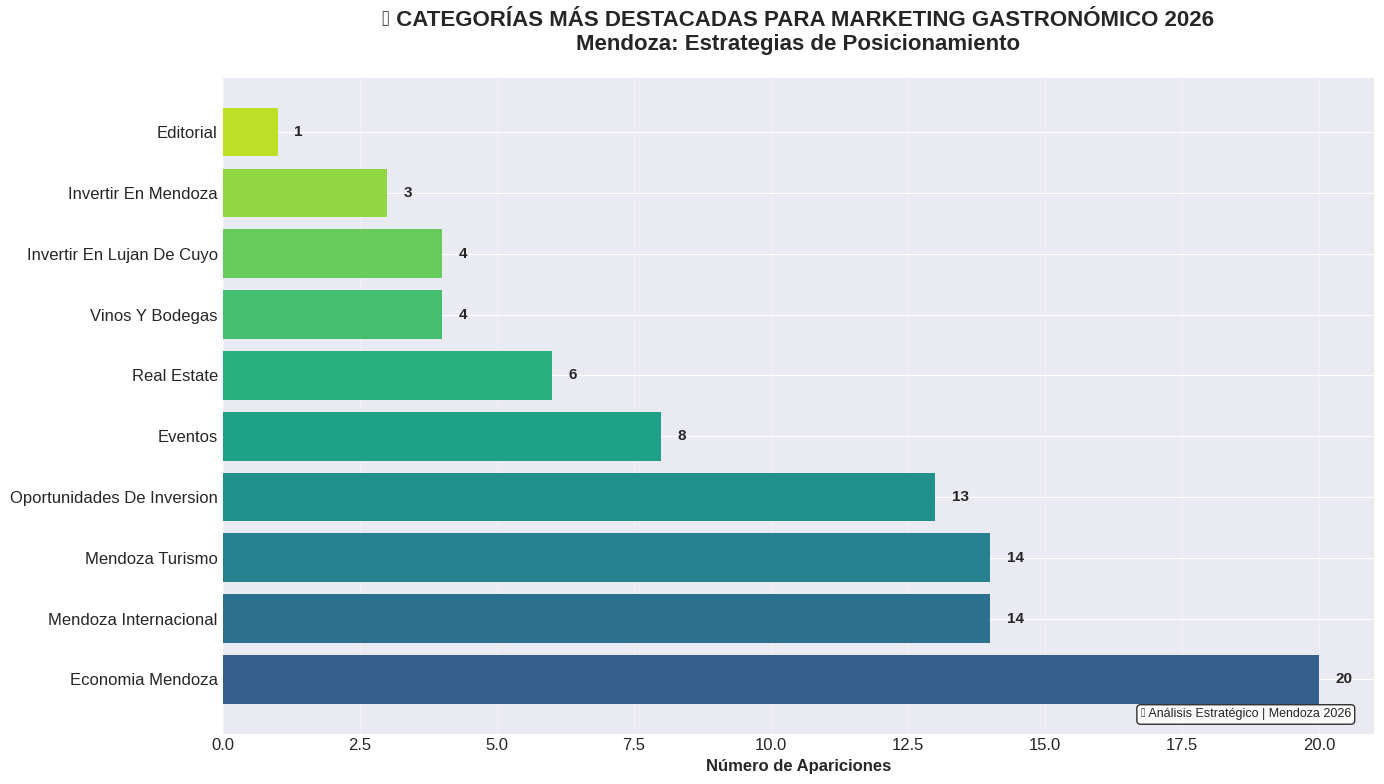

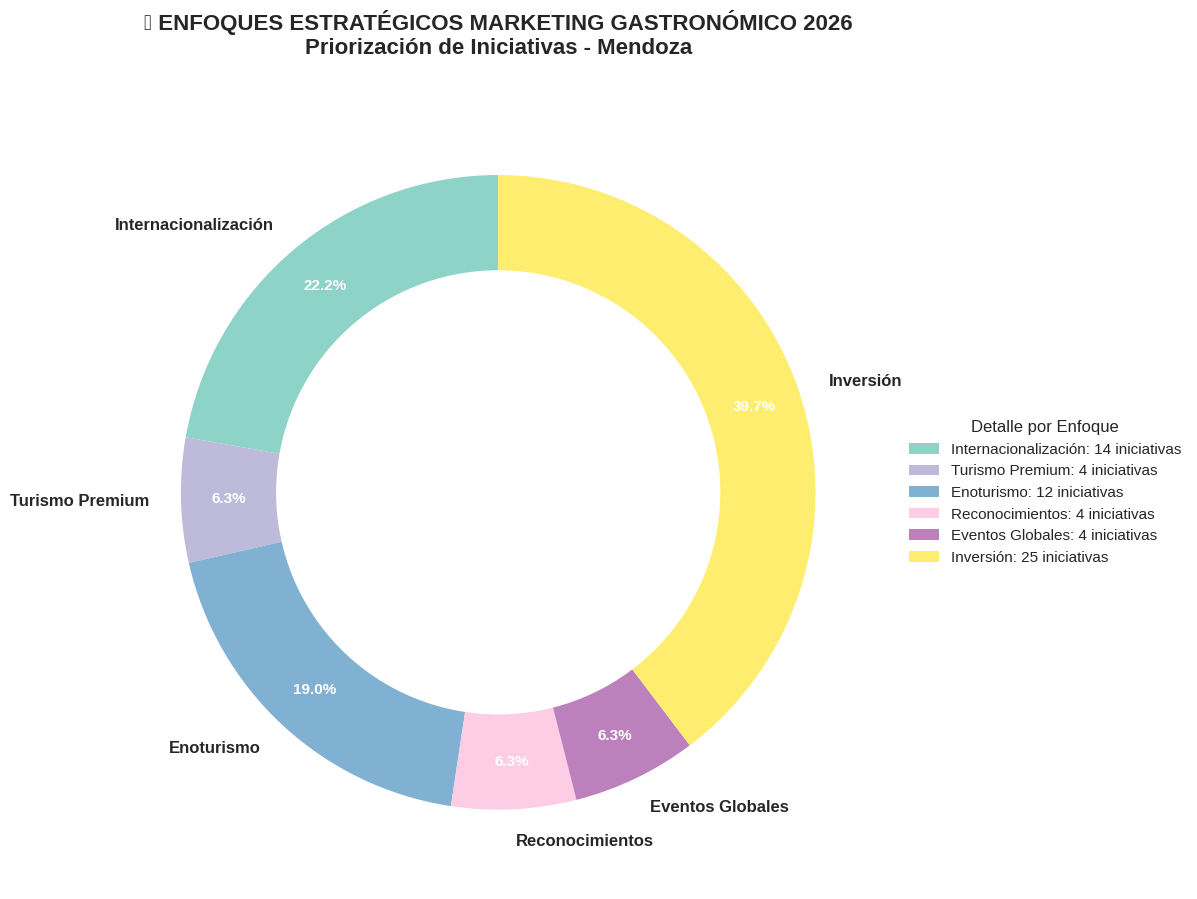

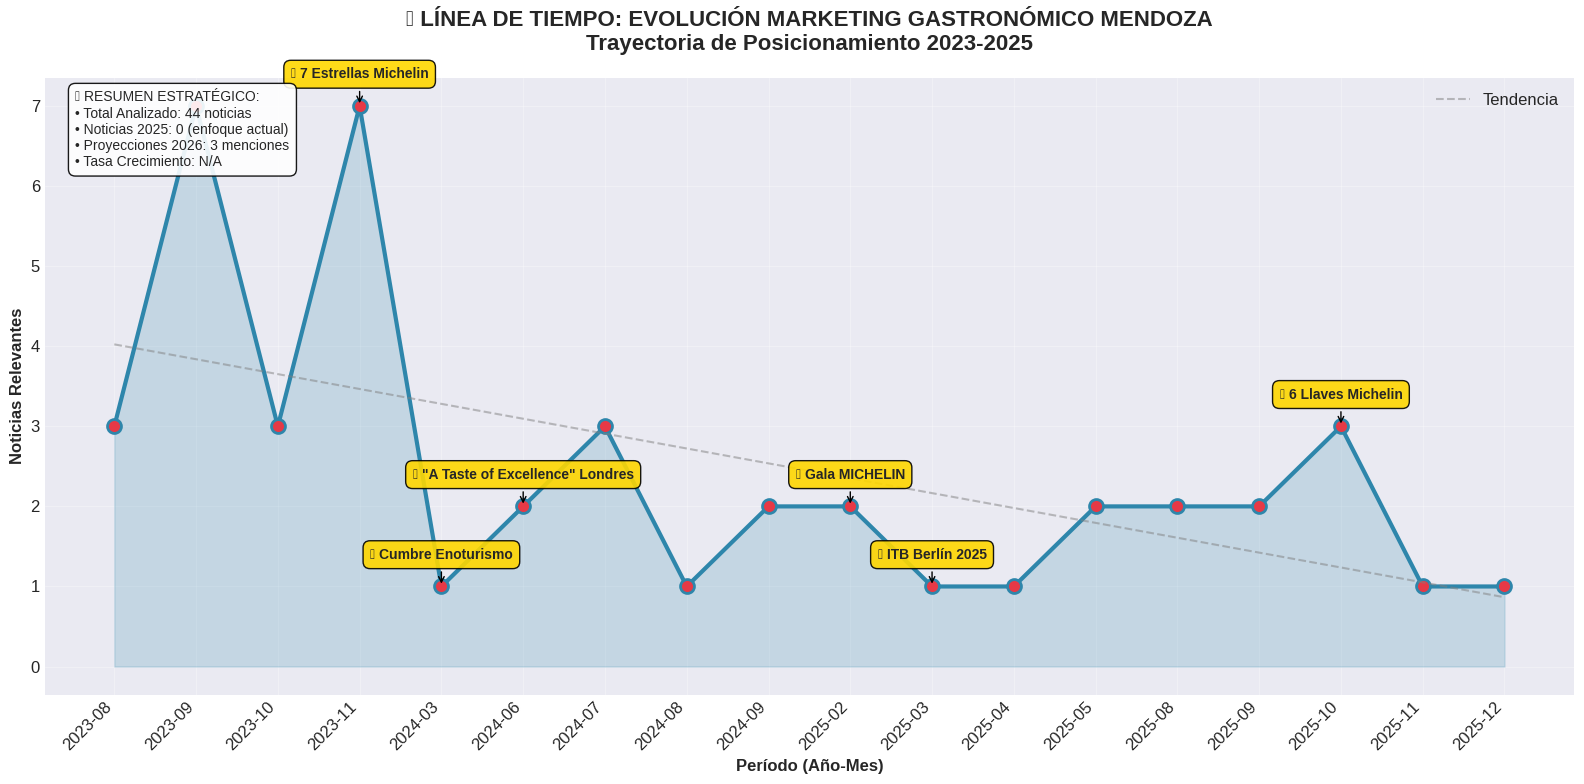

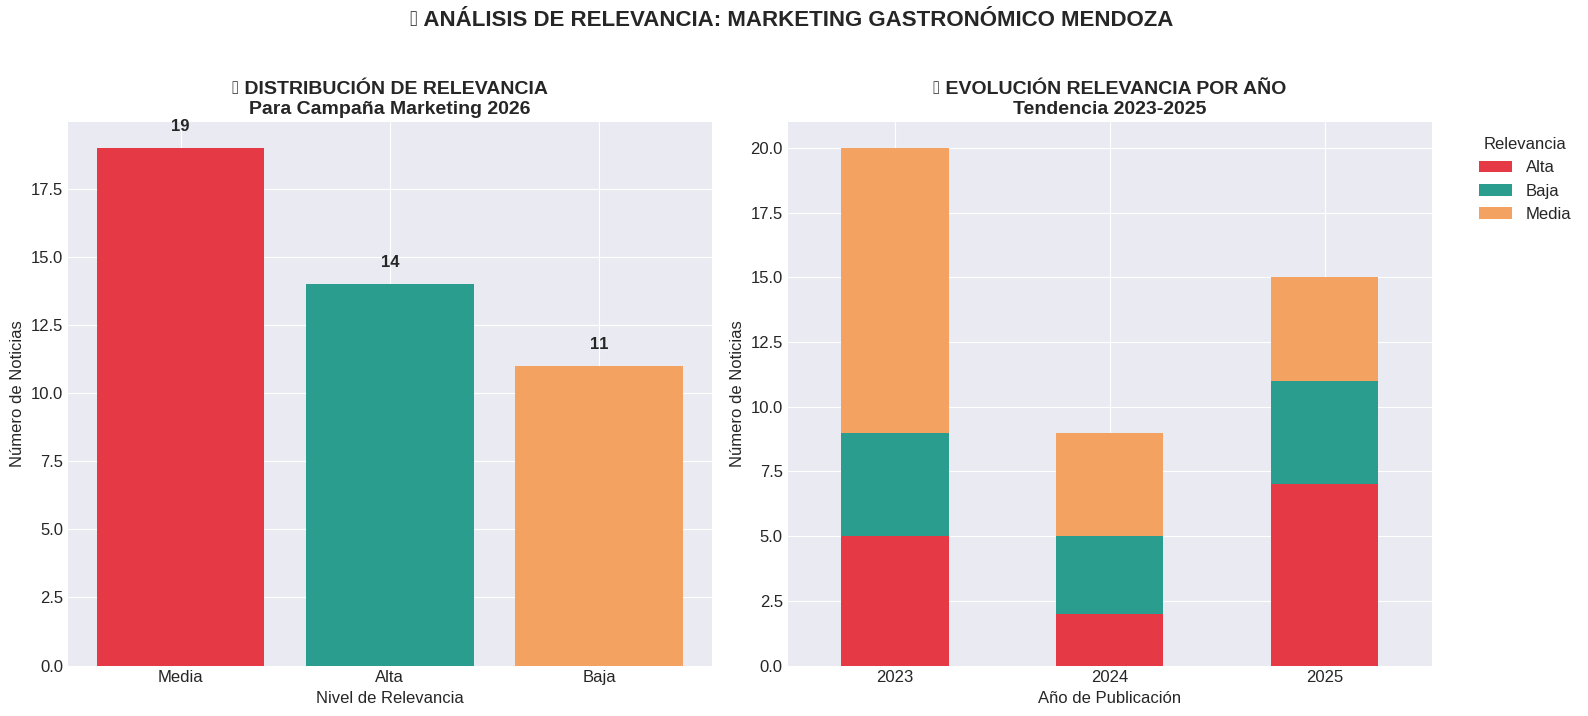

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from collections import Counter

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

df = pd.read_excel('gastronomia_invest_mendoza.xlsx')

# GRÁFICO 1: CATEGORÍAS DESTACADAS
categorias_lista = []
for categorias in df['Categorias']:
    if pd.notna(categorias) and categorias != '':
        cats = [cat.strip() for cat in str(categorias).split(',')]
        categorias_lista.extend(cats)

cat_counter = Counter(categorias_lista)
top_categorias = cat_counter.most_common(10)

fig1, ax1 = plt.subplots(figsize=(14, 8))
categorias_nombres = [cat[0] for cat in top_categorias]
categorias_valores = [cat[1] for cat in top_categorias]

bars = ax1.barh(categorias_nombres, categorias_valores,
                color=plt.cm.viridis(np.linspace(0.3, 0.9, len(categorias_nombres))))

for i, (bar, valor) in enumerate(zip(bars, categorias_valores)):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{valor}', ha='left', va='center',
             fontsize=11, fontweight='bold')

ax1.set_xlabel('Número de Apariciones', fontsize=12, fontweight='bold')
ax1.set_title('🏆 CATEGORÍAS MÁS DESTACADAS PARA MARKETING GASTRONÓMICO 2026\n' +
              'Mendoza: Estrategias de Posicionamiento',
              fontsize=16, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3)

ax1.text(0.98, 0.02, '📈 Análisis Estratégico | Mendoza 2026',
         transform=ax1.transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('categorias_marketing_gastronomico.png', dpi=300, bbox_inches='tight')
plt.show()

# GRÁFICO 2: ENFOQUES ESTRATÉGICOS
enfoques = {
    'Internacionalización': len(df[df['Relevancia_Campana'] == 'Alta']),
    'Turismo Premium': len(df[df['Titulo'].str.contains('lujo|luxury|premium|excelencia', case=False, na=False)]),
    'Enoturismo': len(df[df['Titulo'].str.contains('enoturismo|vino|bodega|wine', case=False, na=False)]),
    'Reconocimientos': len(df[df['Titulo'].str.contains('michelin|estrella|llave|reconocimiento', case=False, na=False)]),
    'Eventos Globales': len(df[df['Titulo'].str.contains('ITB|Berlín|feria|evento|gala', case=False, na=False)]),
    'Inversión': len(df[df['Categorias'].str.contains('Inversion|Real Estate|Economia', na=False)])
}

enfoques = {k: v for k, v in enfoques.items() if v > 0}

fig2, ax2 = plt.subplots(figsize=(12, 12))
colors = plt.cm.Set3(np.linspace(0, 1, len(enfoques)))
wedges, texts, autotexts = ax2.pie(enfoques.values(),
                                   labels=enfoques.keys(),
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   pctdistance=0.85)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax2.add_artist(centre_circle)

ax2.set_title('🎯 ENFOQUES ESTRATÉGICOS MARKETING GASTRONÓMICO 2026\n' +
              'Priorización de Iniciativas - Mendoza',
              fontsize=16, fontweight='bold', pad=30)

legend_labels = [f'{k}: {v} iniciativas' for k, v in enfoques.items()]
ax2.legend(wedges, legend_labels, title="Detalle por Enfoque",
           loc="center left", bbox_to_anchor=(1, 0, 0.5, 1),
           fontsize=11)

plt.tight_layout()
plt.savefig('enfoques_estrategicos_gastronomia.png', dpi=300, bbox_inches='tight')
plt.show()

# GRÁFICO 3: LÍNEA DE TIEMPO
df['Fecha'] = pd.to_datetime(df['Fecha_Datetime'], errors='coerce')
df_timeline = df.sort_values('Fecha')
df_timeline['Año-Mes'] = df_timeline['Fecha'].dt.to_period('M')
timeline_counts = df_timeline['Año-Mes'].value_counts().sort_index()
timeline_counts = timeline_counts[timeline_counts.index >= pd.Period('2023-01', 'M')]

fig3, ax3 = plt.subplots(figsize=(16, 8))
periods = [str(p) for p in timeline_counts.index]
counts = timeline_counts.values

ax3.plot(periods, counts, marker='o', linewidth=3, markersize=10,
         color='#2E86AB', markerfacecolor='#E63946', markeredgewidth=2)

ax3.fill_between(periods, counts, alpha=0.2, color='#2E86AB')

eventos_destacados = {
    '2023-11': '7 Estrellas Michelin',
    '2024-03': 'Cumbre Enoturismo',
    '2024-06': '"A Taste of Excellence" Londres',
    '2025-02': 'Gala MICHELIN',
    '2025-03': 'ITB Berlín 2025',
    '2025-10': '6 Llaves Michelin'
}

for periodo, evento in eventos_destacados.items():
    if periodo in periods:
        idx = periods.index(periodo)
        ax3.annotate(f'⭐ {evento}',
                    xy=(periodo, counts[idx]),
                    xytext=(0, 20),
                    textcoords='offset points',
                    ha='center',
                    fontsize=10,
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='gold', alpha=0.9),
                    arrowprops=dict(arrowstyle='->', color='black'))

ax3.set_xlabel('Período (Año-Mes)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Noticias Relevantes', fontsize=12, fontweight='bold')
ax3.set_title('📈 LÍNEA DE TIEMPO: EVOLUCIÓN MARKETING GASTRONÓMICO MENDOZA\n' +
              'Trayectoria de Posicionamiento 2023-2025',
              fontsize=16, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right')

if len(counts) > 1:
    z = np.polyfit(range(len(counts)), counts, 1)
    p = np.poly1d(z)
    ax3.plot(periods, p(range(len(counts))), "--", alpha=0.5, color='gray',
             label='Tendencia')
    ax3.legend()

ax3.grid(True, alpha=0.3)

total_noticias = len(df)
noticias_2025 = len(df[df['Año_Publicacion'] == '2025'])
proyeccion_futura = len(df[df['Es_Proyeccion_Futura'] == 'Sí'])

noticias_2023 = len(df[df['Año_Publicacion'] == '2023'])
if noticias_2023 > 0:
    tasa_crecimiento = ((noticias_2025 / noticias_2023) - 1) * 100
    tasa_text = f'{tasa_crecimiento:.1f}%'
else:
    tasa_text = 'N/A'

stats_text = f'''📊 RESUMEN ESTRATÉGICO:
• Total Analizado: {total_noticias} noticias
• Noticias 2025: {noticias_2025} (enfoque actual)
• Proyecciones 2026: {proyeccion_futura} menciones
• Tasa Crecimiento: {tasa_text}'''

ax3.text(0.02, 0.98, stats_text,
         transform=ax3.transAxes, fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.savefig('linea_tiempo_marketing_gastronomia.png', dpi=300, bbox_inches='tight')
plt.show()

# GRÁFICO 4: RELEVANCIA POR AÑO
fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(16, 7))

relevancia_counts = df['Relevancia_Campana'].value_counts()
colors_relevancia = ['#E63946', '#2A9D8F', '#F4A261']
bars_relevancia = ax4a.bar(relevancia_counts.index, relevancia_counts.values,
                           color=colors_relevancia[:len(relevancia_counts)])

ax4a.set_title('📊 DISTRIBUCIÓN DE RELEVANCIA\nPara Campaña Marketing 2026',
               fontsize=14, fontweight='bold')
ax4a.set_ylabel('Número de Noticias', fontsize=12)
ax4a.set_xlabel('Nivel de Relevancia', fontsize=12)

for bar in bars_relevancia:
    height = bar.get_height()
    ax4a.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

df_relevancia_anio = df.groupby(['Año_Publicacion', 'Relevancia_Campana']).size().unstack(fill_value=0)
if not df_relevancia_anio.empty:
    df_relevancia_anio.plot(kind='bar', stacked=True, ax=ax4b,
                           color=colors_relevancia[:len(relevancia_counts)])
    ax4b.set_title('📈 EVOLUCIÓN RELEVANCIA POR AÑO\nTendencia 2023-2025',
                   fontsize=14, fontweight='bold')
    ax4b.set_ylabel('Número de Noticias', fontsize=12)
    ax4b.set_xlabel('Año de Publicación', fontsize=12)
    ax4b.legend(title='Relevancia', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.setp(ax4b.xaxis.get_majorticklabels(), rotation=0)

plt.suptitle('🎯 ANÁLISIS DE RELEVANCIA: MARKETING GASTRONÓMICO MENDOZA',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('relevancia_marketing_gastronomia.png', dpi=300, bbox_inches='tight')
plt.show()